## SARIMAX

**Objetivo:** desenvolver um modelo de previsão de PM2.5 utilizando SARIMAX, incorporando variáveis meteorológicas e sazonalidades temporais para previsão das próximas 24 horas.

- Avaliando ciclos sazonais e correlação entre variáveis
- VIF (variáveis atmosféricas)
- Estacionaridade

In [43]:
%matplotlib widget

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

### 1. Carregamento dos dados

In [45]:
# abrindo base de dados para treinamento - testando inicialmente com a série original com gaps
data = pd.read_csv("../data/data_sem_interpolacao/dados_pm25_umi_temp_2016_2019_nan.csv")
#data = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/dados_pm25_umi_temp_2016_2019_fill_mean.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490


In [46]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m
time,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490


### 2. Exploração da Série Temporal (Ciclos)

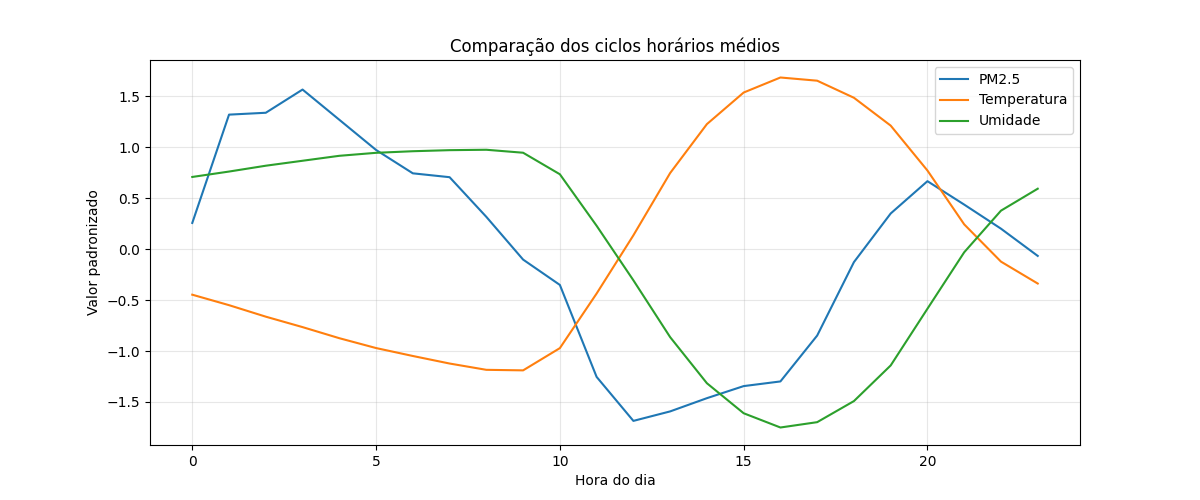

In [47]:
#ciclo diário
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.hour)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.hour)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.hour)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos horários médios")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.show()

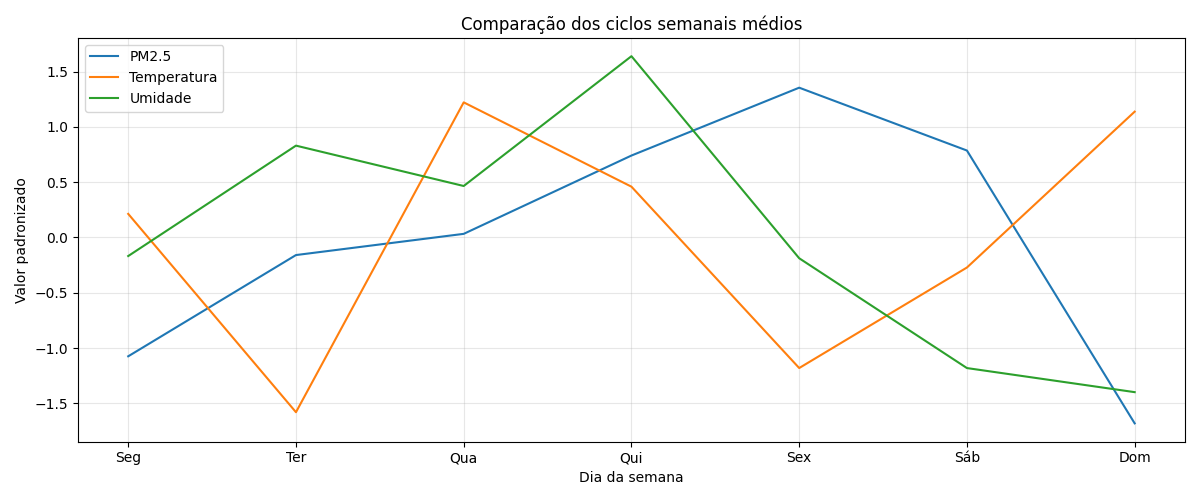

In [48]:
# ciclo semanal
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.dayofweek)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.dayofweek)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.dayofweek)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ciclo_norm.index = dias

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos semanais médios")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

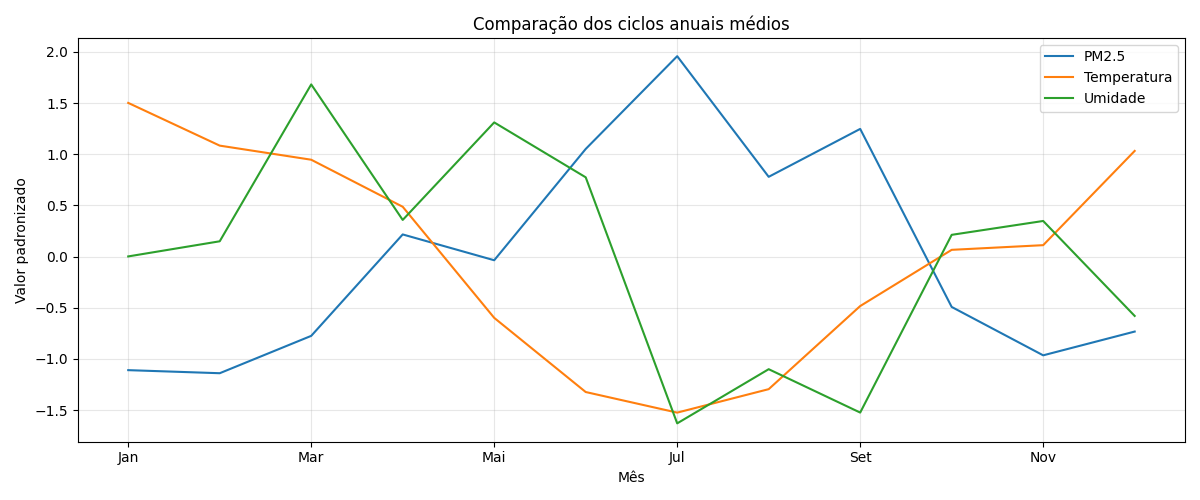

In [49]:
# ciclo anual
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.month)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.month)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.month)["relative_humidity_2m"].mean()
})


ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

ciclo_norm.index = meses

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos anuais médios")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Correlação entre variáveis

In [50]:
######### Temperatura e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_temp = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["temperature_2m"].shift(lag)
    )

    corr_temp.append(c)

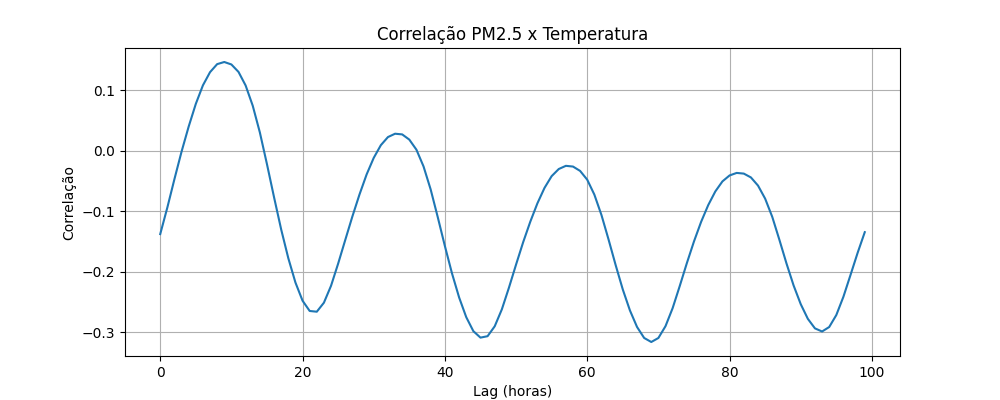

In [51]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Temperatura")
plt.grid()

plt.show()

In [52]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi.append(c)

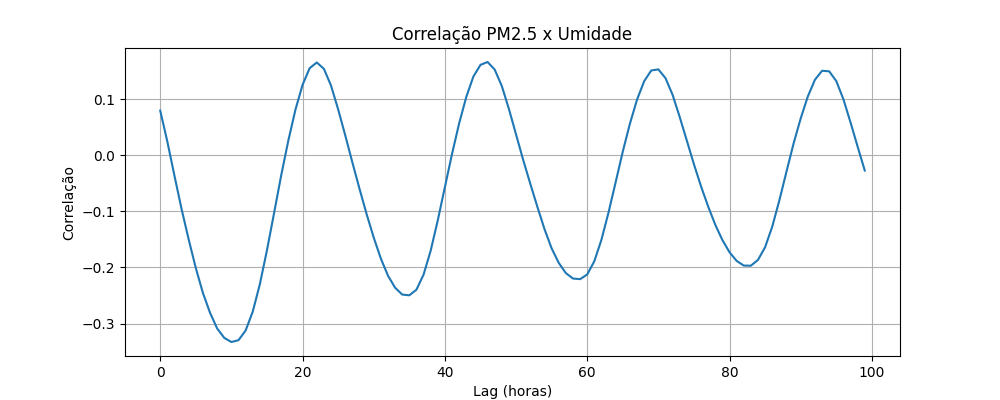

In [53]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Umidade")
plt.grid()

plt.show()

In [54]:
corr_pm25 = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["MP2.5"].shift(lag)
    )

    corr_pm25.append(c)

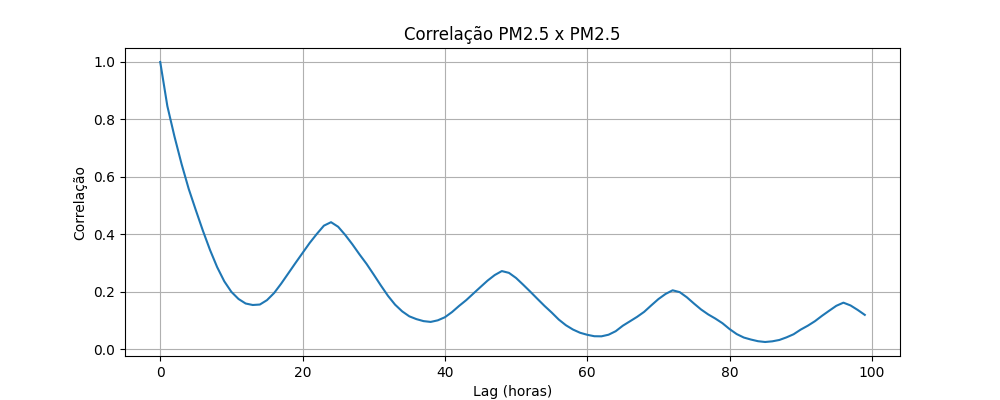

In [55]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_pm25)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x PM2.5")
plt.grid()

plt.show()

In [56]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi_temp = []

for lag in range(0, 100):

    c = data["temperature_2m"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi_temp.append(c)

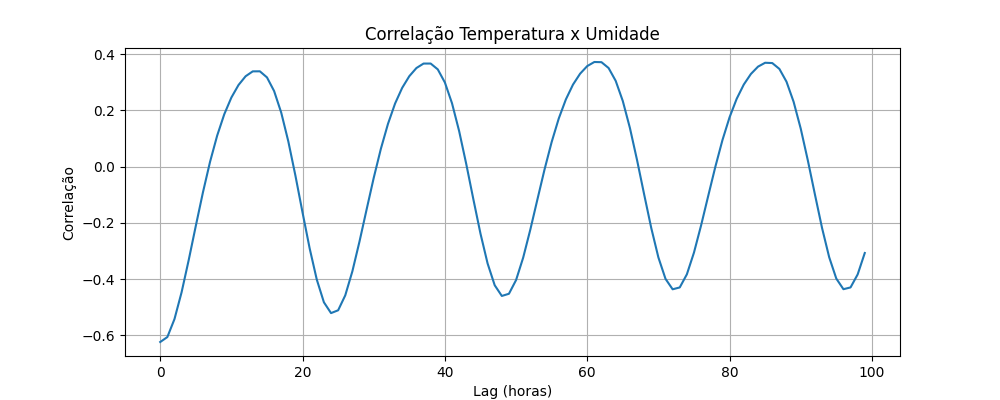

In [57]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação Temperatura x Umidade")
plt.grid()

plt.show()

### 4. VIF (Variance Inflation Factor): Investigando multicolinearidade entre as features

In [58]:
# normalizando utilizando StandardScaler()
cols = [
    "temperature_2m",
    "relative_humidity_2m"
]

scaler = StandardScaler()

data_scaled = data.drop(columns=["MP2.5"]).copy()
#data_scaled = data.copy()

data_scaled[cols] = scaler.fit_transform(
    data_scaled[cols]
)

data_scaled.head()

,temperature_2m,relative_humidity_2m
time,,
2016-03-01 00:00:00+00:00,-0.303972,0.807668
2016-03-01 01:00:00+00:00,-0.292856,0.867885
2016-03-01 02:00:00+00:00,-0.281741,0.827881
2016-03-01 03:00:00+00:00,-0.303972,0.887937
2016-03-01 04:00:00+00:00,-0.292856,0.867885


In [59]:
#Considerar VIF ≥  10 como um potencial problema

df = pd.DataFrame()

df["features"] = data_scaled.columns

df["vif_index"] = [vif(data_scaled.values, i) for i in range(data_scaled.shape[1])]

round(df.sort_values(by="vif_index", ascending = False),2)

,features,vif_index
0,temperature_2m,1.64
1,relative_humidity_2m,1.64


### 5. Entendendo estacionaridade e defasegem de PM2.5

In [60]:
# # Avaliando período máximo contínuo sem gaps temporais para análise.
# # Tentei fazer a análise com a série completa mas como tem gaps quis comparar também com uma série contínua
# # para ter certeza que os gaps não estavam influenciando as estimativas, principalmente da estacionaridade.

# def encontrar_segmentos_continuos(df, col="MP2.5", freq="h"):
#     serie = df[col].copy()

#     serie = serie.sort_index().asfreq(freq)

#     valido = serie.notna()

#     grupo = (valido != valido.shift()).cumsum()

#     segmentos = []

#     for _, bloco in serie.groupby(grupo):
#         if bloco.notna().all():
#             segmentos.append({
#                 "inicio": bloco.index[0],
#                 "fim": bloco.index[-1],
#                 "n_horas": len(bloco),
#                 "n_dias": len(bloco) / 24
#             })

#     segmentos = pd.DataFrame(segmentos)

#     if segmentos.empty:
#         return segmentos

#     return segmentos.sort_values("n_horas", ascending=False).reset_index(drop=True)

In [61]:
# segmentos = encontrar_segmentos_continuos(data, col="MP2.5", freq="h")
# segmentos.head(10)

In [62]:
# maior = segmentos.iloc[0]

# inicio = maior["inicio"]
# fim = maior["fim"]

# data_continua = data.loc[inicio:fim].copy()

# print(inicio, fim)
# print(f"{maior['n_dias']:.1f} dias contínuos")

In [63]:
# # Avaliando impactos diretos e indiretos de PM2.5
# def plot_autocorrelation(y, d=0, D=0, m=0):
#     y = pd.Series(y)
#     if D > 0:
#         for i in range(D):
#             y = y.diff(m)
#     if d > 0:
#         for i in range(d):
#             y = y.diff(1)
#     fig = plt.figure(figsize=(20,10))
#     ax1 = fig.add_subplot(2,1,1)
#     ax2 = fig.add_subplot(2,2,3)
#     ax3 = fig.add_subplot(2,2,4)
#     ax1.plot(y)
#     plot_acf(y, lags = 50, ax=ax2);
#     plot_pacf(y, lags=50, method='ywm', ax=ax3, color='r');
#     plt.show()

In [64]:
# plot_autocorrelation(data_continua["MP2.5"], d=0, D=0, m=24)

In [65]:
# plot_autocorrelation(data_continua["MP2.5"],d=0,D=1,m=24)

Avaliando a Estacionaridade

**************
O p-valor deve ser menor que 0,05 para que possamos ter 95% de confiança de que a série é estacionária.

Idealmente, o p-valor deve ser muito menor que 0,05.
*************
seasonal_order=(P,1,Q,24)

In [66]:
# result = adfuller(data_continua["MP2.5"])

# print("ADF statistic:", result[0])
# print("p-value:", result[1])

### 6. Separando conjunto de treino e teste

In [67]:
# cortando a série para teste pq o treino travou
metade = int(len(data)*0.5)
data_50 = data.iloc[:metade]

# separando em teste e treino 70% para treino e 30% para teste
train_size = 0.7

index = round(train_size*data_50.shape[0])
df_train = data_50.iloc[:index]
df_test = data_50.iloc[index+1:]

y = data_50["MP2.5"]
y_train = df_train["MP2.5"]
y_test = df_test["MP2.5"]

# # testando inicialmente somente com temperatura como exogena
# exog = data_50['temperature_2m']
# exog_train = df_train['temperature_2m']
# exog_test = df_test['temperature_2m']

# exógenas completas
cols_exog = [
    "temperature_2m",
    "relative_humidity_2m"
]

exog = data_50[cols_exog]

exog_train = df_train[cols_exog]

exog_test = df_test[cols_exog]

In [68]:
from dateutil.relativedelta import relativedelta

print(f'Intevalo de treino: {y_train.index[0]} a {y_train.index[-1]}')
diff = relativedelta(y_train.index[-1], y_train.index[0])
print(diff)

print(f'Intevalo de teste: {y_test.index[0]} a {y_test.index[0]}')
diff = relativedelta(y_test.index[-1], y_test.index[0])
print(diff)

Intevalo de treino: 2016-03-01 00:00:00+00:00 a 2017-05-17 18:00:00+00:00
relativedelta(years=+1, months=+2, days=+16, hours=+18)
Intevalo de teste: 2017-05-17 20:00:00+00:00 a 2017-05-17 20:00:00+00:00
relativedelta(months=+6, days=+5, hours=+16)


### 7. Modelagem

  Ref. https://skforecast.org/latest/user_guides/forecasting-sarimax-arima.html

  https://www.geeksforgeeks.org/python/complete-guide-to-sarimax-in-python/



In [69]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# p=2 (PACF), d=0 (estacionaria), q=1 (ACF), m=24 (ciclo diário é o meu forte) - exp.1
# p=2 (PACF), d=1 (diferenciação sazonal), q=1 (ACF), m=24 (ciclo diário é o meu forte) - exp.2
seasonal_order = (1,1,1,24)
order = (1,0,1)

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order
)

/home/izabel/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/izabel/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [70]:
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *



 This problem is unconstrained.


Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.23771D+00    |proj g|=  1.11172D-01

At iterate    5    f=  3.09297D+00    |proj g|=  5.13597D-02

At iterate   10    f=  3.08765D+00    |proj g|=  1.01717D-02

At iterate   15    f=  3.08654D+00    |proj g|=  1.74729D-03

At iterate   20    f=  3.08647D+00    |proj g|=  3.22347D-03

At iterate   25    f=  3.08644D+00    |proj g|=  2.41060D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    7     27     30      1     0     0   2.329D-05   3.086D+00
  F =   3.0864412073985

In [77]:
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              MP2.5   No. Observations:                10627
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -32799.611
Date:                            Sat, 13 Jun 2026   AIC                          65613.221
Time:                                    17:44:32   BIC                          65664.104
Sample:                                03-01-2016   HQIC                         65630.395
                                     - 05-17-2017                                         
Covariance Type:                              opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
temperature_2m           0.2061      0.118      1.750      0.080      -0.025       0.437
relat

In [78]:
# previsão das próximas 24h
forecast_24h = results.get_forecast(
    steps=24,
    exog=exog_test.iloc[:24]
)

forecast_mean = forecast_24h.predicted_mean
conf_int = forecast_24h.conf_int()

index_forecast = y_test.index[:24]

# # índice futuro
# index_forecast = pd.date_range(
#     start=y_train.index[-1] + pd.Timedelta(hours=1),
#     periods=24,
#     freq="h"
# )

forecast_mean.index = index_forecast
conf_int.index = index_forecast

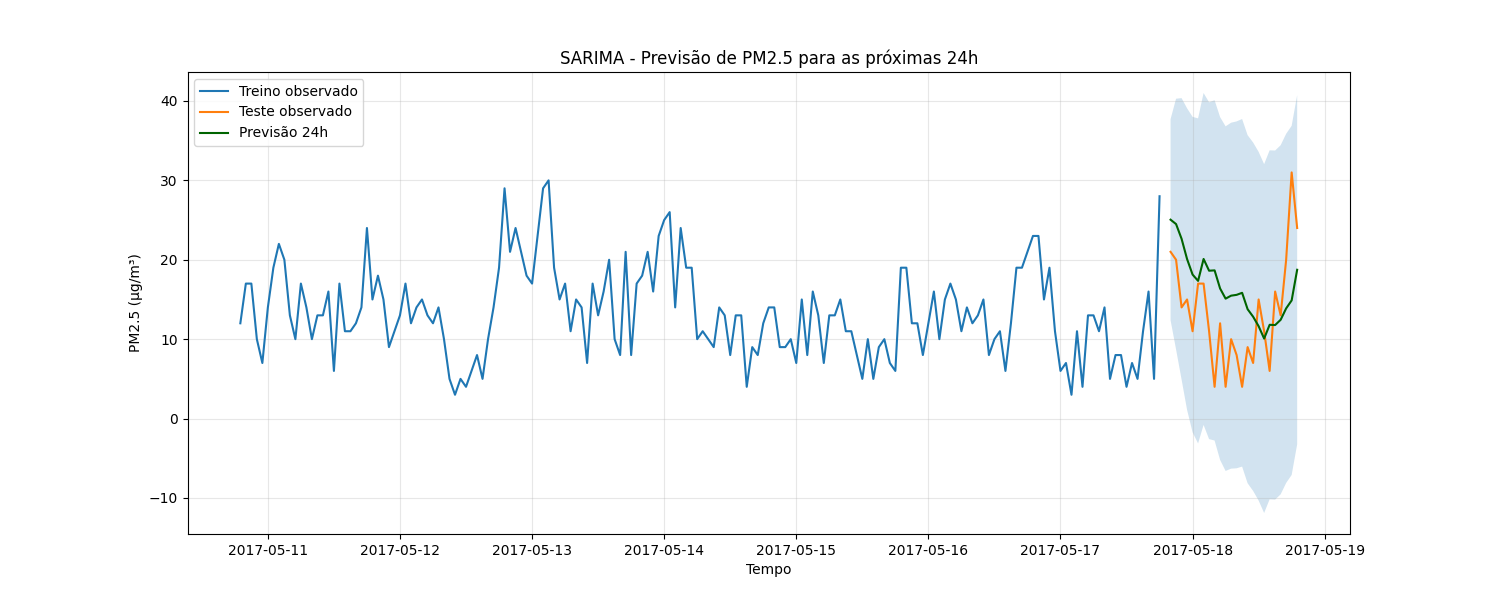

In [79]:
# Figura
plt.figure(figsize=(15, 6))

# últimos dias observados
plt.plot(
    y_train.iloc[-24*7:],
    label="Treino observado"
)

# comparar somente com +24h
plt.plot(
    y_test.iloc[:24],
    label="Teste observado"
)


plt.plot(
    forecast_mean,
    label="Previsão 24h",
    color="darkgreen"
)


plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2
)

plt.title("SARIMA - Previsão de PM2.5 para as próximas 24h")
plt.xlabel("Tempo")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [80]:
from sklearn.metrics import mean_absolute_error

error_mae = mean_absolute_error(
                y_true = y_test.iloc[:24],
                y_pred = forecast_mean
            )
print(f"Test error (mae): {error_mae}")

Test error (mae): 6.187498440177535


In [81]:
from sklearn.metrics import root_mean_squared_error

error_rmse = root_mean_squared_error(
    y_true=y_test.iloc[:24],
    y_pred=forecast_mean
)

print(f"Test error (RMSE): {error_rmse:.3f}")

Test error (RMSE): 7.322


In [82]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_true=y_test.iloc[:24],
    y_pred=forecast_mean
)

print(f"R²: {r2:.4f}")

R²: -0.2310


### 8. Experimentos

Experimento 01 - 70% dos dados (2016-2019), sem interpolar, usando variáveis exogenas (temp_umi)

    seasonal_order=(2,0,1,24)
    Test error (mae): 8.411993014511117
    Test error (RMSE): 9.388
    R²: -1.7497


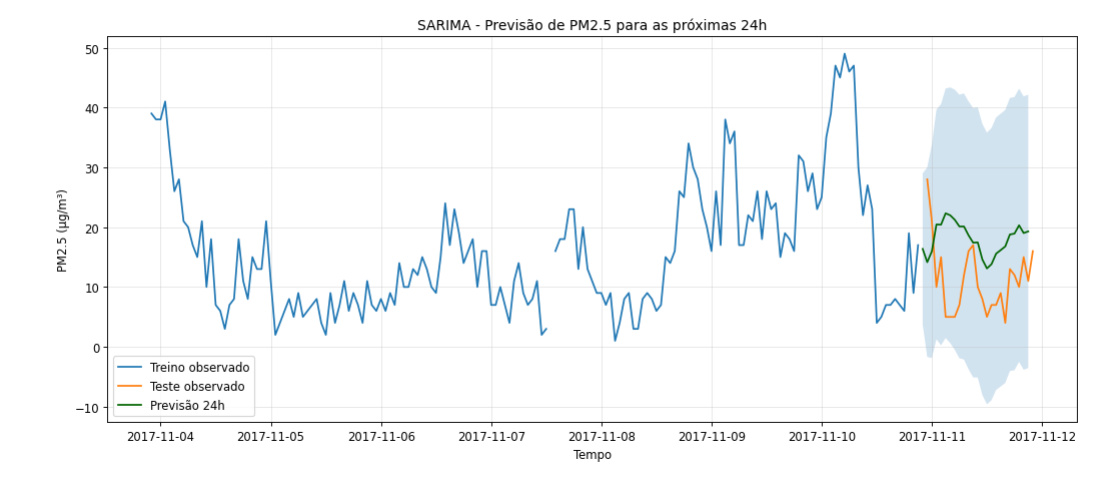

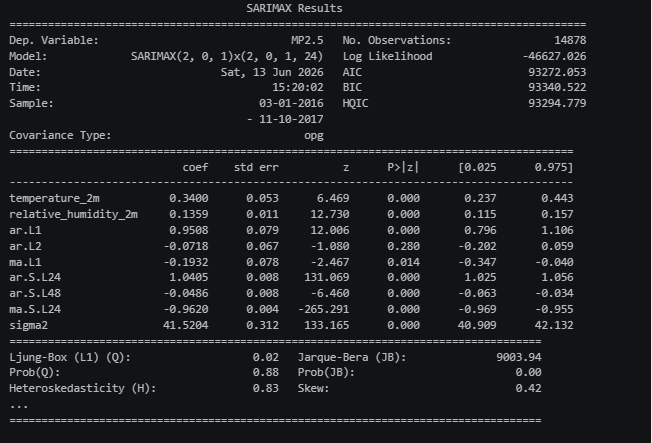



Experimento 02 - 50% dos dados dos dados (2016-2019), com interpolar, usando variáveis exogenas (temp_umi)
seasonal_order = (1,1,1,24)
order = (1,0,1)

Test error (mae): 6.715100410694242
Test error (RMSE): 7.868
R²: -0.4212

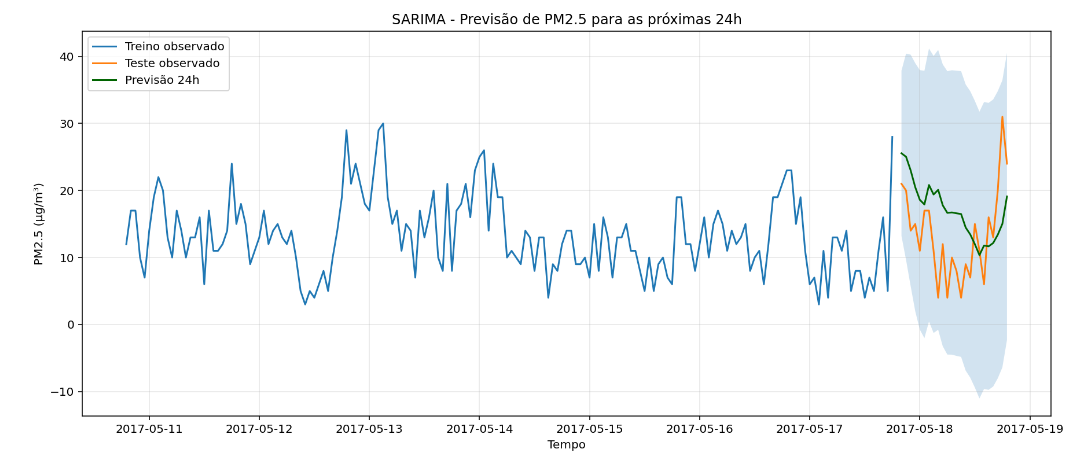

Experimento 3: 50% dos dados dos dados (2016-2019), sem interpolar, usando variáveis exogenas (temp_umi)
seasonal_order = (1,1,1,24)
order = (1,0,1)

Test error (mae): 6.187498440177535
Test error (RMSE): 7.322
R²: -0.2310

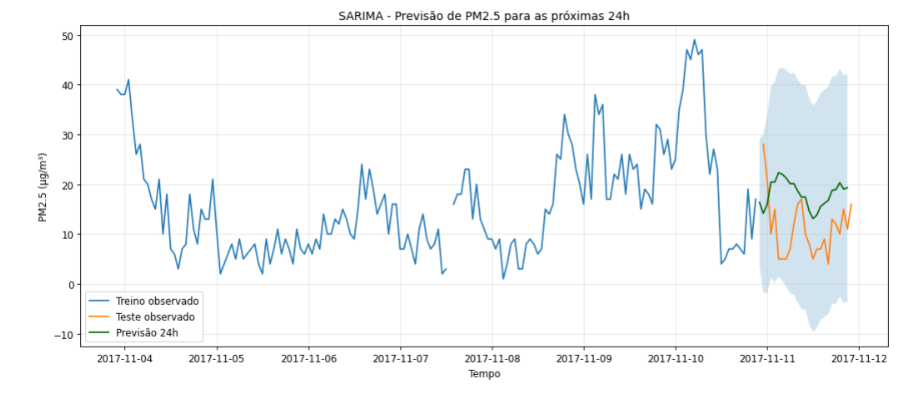